**Aula 05 — Pipeline Único + Múltiplos Modelos (Iris)**

---

**Disciplina:** Inteligência Artificial  
**Professor:** Marcelo Batista

🎯 **OBJETIVOS**

Em vez de criar um Pipeline para cada modelo, você cria um Pipeline de pré-processamento e depois o aplica a vários modelos. Assim:✅ Dados são preparados uma única vez

- Todos os modelos recebem os mesmos dados
- Comparação é justa e reprodutível
- Código fica limpo e profissional

 ### Importações e Carregamento de Dados

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings('ignore')

# 1. Carregar dados
df = sns.load_dataset("iris")
X = df.drop("species", axis=1)
y = df["species"]

# 2. Dividir em Treino/Teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Dados carregados!")
print(f"   Treino: {X_train.shape[0]} amostras")
print(f"   Teste: {X_test.shape[0]} amostras")

✅ Dados carregados!
   Treino: 120 amostras
   Teste: 30 amostras


### Criar o Pipeline de Pré-Processamento (Uma Única Vez!)

In [2]:
# 🔧 PIPELINE DE PRÉ-PROCESSAMENTO ÚNICO
# Este pipeline será reutilizado para TODOS os modelos

# Identificar colunas numéricas e categóricas
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"\n📊 Colunas numéricas: {num_cols}")
print(f"📊 Colunas categóricas: {cat_cols}")

# Criar o ColumnTransformer (o "chef" que prepara os dados)
preprocessor = ColumnTransformer([
    # Bloco 1: Preparar colunas NUMÉRICAS
    ("num", Pipeline([
        ("scaler", StandardScaler())  # Padronizar
    ]), num_cols),

    # Bloco 2: Colunas CATEGÓRICAS (Iris não tem, mas deixamos pronto)
    ("cat", Pipeline([
        # Aqui iríamos colocar OneHotEncoder se tivéssemos categorias
    ]), cat_cols) if cat_cols else ("cat", "passthrough", [])
])

# Aplicar o preprocessor aos dados
print("\n⚙️ Aplicando pré-processamento...")
X_train_processed = preprocessor.fit_transform(X_train)  # Fit + Transform no treino
X_test_processed = preprocessor.transform(X_test)        # Apenas Transform no teste

print(f"✅ Dados pré-processados!")
print(f"   Shape treino: {X_train_processed.shape}")
print(f"   Shape teste: {X_test_processed.shape}")

# Mostrar antes e depois
print(f"\n📊 Antes do pré-processamento (primeira linha):")
print(f"   {X_train.iloc[0].values}")
print(f"\n⚖️ Depois do pré-processamento (primeira linha):")
print(f"   {np.round(X_train_processed[0], 2)}")


📊 Colunas numéricas: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
📊 Colunas categóricas: []

⚙️ Aplicando pré-processamento...
✅ Dados pré-processados!
   Shape treino: (120, 4)
   Shape teste: (30, 4)

📊 Antes do pré-processamento (primeira linha):
   [4.6 3.6 1.  0.2]

⚖️ Depois do pré-processamento (primeira linha):
   [-1.47  1.2  -1.56 -1.31]


### Treinar Múltiplos Modelos com os Dados Pré-Processados

In [3]:
# 🚀 MODELO 1: REDE NEURAL (MLP)
print("\n" + "="*60)
print("🧠 MODELO 1: REDE NEURAL (MLP)")
print("="*60)

modelo_rn = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    max_iter=1000,
    random_state=42
)

print("Treinando Rede Neural...")
modelo_rn.fit(X_train_processed, y_train)

# Previsões
pred_rn = modelo_rn.predict(X_test_processed)
acc_rn = accuracy_score(y_test, pred_rn)

print(f"✅ Acurácia (Rede Neural): {acc_rn * 100:.2f}%")
print("\nRelatório de Classificação:")
print(classification_report(y_test, pred_rn))

# ---

# 🌲 MODELO 2: RANDOM FOREST
print("\n" + "="*60)
print("🌲 MODELO 2: RANDOM FOREST")
print("="*60)

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

print("Treinando Random Forest...")
modelo_rf.fit(X_train_processed, y_train)

# Previsões
pred_rf = modelo_rf.predict(X_test_processed)
acc_rf = accuracy_score(y_test, pred_rf)

print(f"✅ Acurácia (Random Forest): {acc_rf * 100:.2f}%")
print("\nRelatório de Classificação:")
print(classification_report(y_test, pred_rf))

# Importância das features
print("\n🔍 Importância das Features (Random Forest):")
for nome, importancia in zip(X.columns, modelo_rf.feature_importances_):
    print(f"   {nome}: {importancia:.4f}")

# ---

# 📈 MODELO 3: REGRESSÃO LOGÍSTICA
print("\n" + "="*60)
print("📈 MODELO 3: REGRESSÃO LOGÍSTICA")
print("="*60)

modelo_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("Treinando Regressão Logística...")
modelo_lr.fit(X_train_processed, y_train)

# Previsões
pred_lr = modelo_lr.predict(X_test_processed)
acc_lr = accuracy_score(y_test, pred_lr)

print(f"✅ Acurácia (Regressão Logística): {acc_lr * 100:.2f}%")
print("\nRelatório de Classificação:")
print(classification_report(y_test, pred_lr))


🧠 MODELO 1: REDE NEURAL (MLP)
Treinando Rede Neural...
✅ Acurácia (Rede Neural): 96.67%

Relatório de Classificação:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30


🌲 MODELO 2: RANDOM FOREST
Treinando Random Forest...
✅ Acurácia (Random Forest): 100.00%

Relatório de Classificação:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30




### Comparação Lado a Lado

In [4]:
# 📊 COMPARAÇÃO FINAL
print("\n" + "="*60)
print("📊 COMPARAÇÃO DE TODOS OS MODELOS")
print("="*60)

resultados = {
    "Rede Neural (MLP)": acc_rn,
    "Random Forest": acc_rf,
    "Regressão Logística": acc_lr
}

# Ordenar por acurácia
resultados_ordenados = sorted(resultados.items(), key=lambda x: x[1], reverse=True)

print("\n🏆 Ranking de Acurácia:\n")
for i, (modelo, acuracia) in enumerate(resultados_ordenados, 1):
    print(f"{i}. {modelo:.<40} {acuracia * 100:.2f}%")

# Melhor modelo
melhor_modelo = resultados_ordenados[0][0]
melhor_acc = resultados_ordenados[0][1]

print(f"\n🥇 Melhor Modelo: {melhor_modelo} ({melhor_acc * 100:.2f}%)")


📊 COMPARAÇÃO DE TODOS OS MODELOS

🏆 Ranking de Acurácia:

1. Random Forest........................... 100.00%
2. Regressão Logística..................... 100.00%
3. Rede Neural (MLP)....................... 96.67%

🥇 Melhor Modelo: Random Forest (100.00%)


### Teste "Mundo Real" com Todos os Modelos

In [5]:
# 🌸 TESTE COM UMA NOVA FLOR
print("\n" + "="*60)
print("🌸 TESTE COM UMA NOVA FLOR")
print("="*60)

# Nova flor (dados brutos)
nova_flor = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=X.columns)

# Aplicar o MESMO preprocessor
nova_flor_processed = preprocessor.transform(nova_flor)

print(f"\nFlor original: {nova_flor.values[0]}")
print(f"Flor processada: {np.round(nova_flor_processed[0], 2)}")

# Previsões de todos os modelos
print("\n🔮 Previsões dos Modelos:")
print(f"   Rede Neural: {modelo_rn.predict(nova_flor_processed)[0].upper()}")
print(f"   Random Forest: {modelo_rf.predict(nova_flor_processed)[0].upper()}")
print(f"   Regressão Logística: {modelo_lr.predict(nova_flor_processed)[0].upper()}")


🌸 TESTE COM UMA NOVA FLOR

Flor original: [5.1 3.5 1.4 0.2]
Flor processada: [-0.86  0.98 -1.33 -1.31]

🔮 Previsões dos Modelos:
   Rede Neural: SETOSA
   Random Forest: SETOSA
   Regressão Logística: SETOSA


### Pontos-Chave para Fixar

- Pipeline de pré-processamento é criado UMA VEZ
- Fit no treino, transform no teste (nunca vazar informação!)
- Todos os modelos recebem os MESMOS dados
- Comparação é justa e reprodutível
- Reutilizar o preprocessor para novos dados (nova_flor_processed)
- Código fica limpo, profissional e escalável

### Diagrama do Processo - Graphviz + Matplotlib

⏳ Gerando diagrama Graphviz...
✅ Diagrama salvo como 'pipeline_ml_graphviz.png'

📺 Exibindo diagrama na tela...



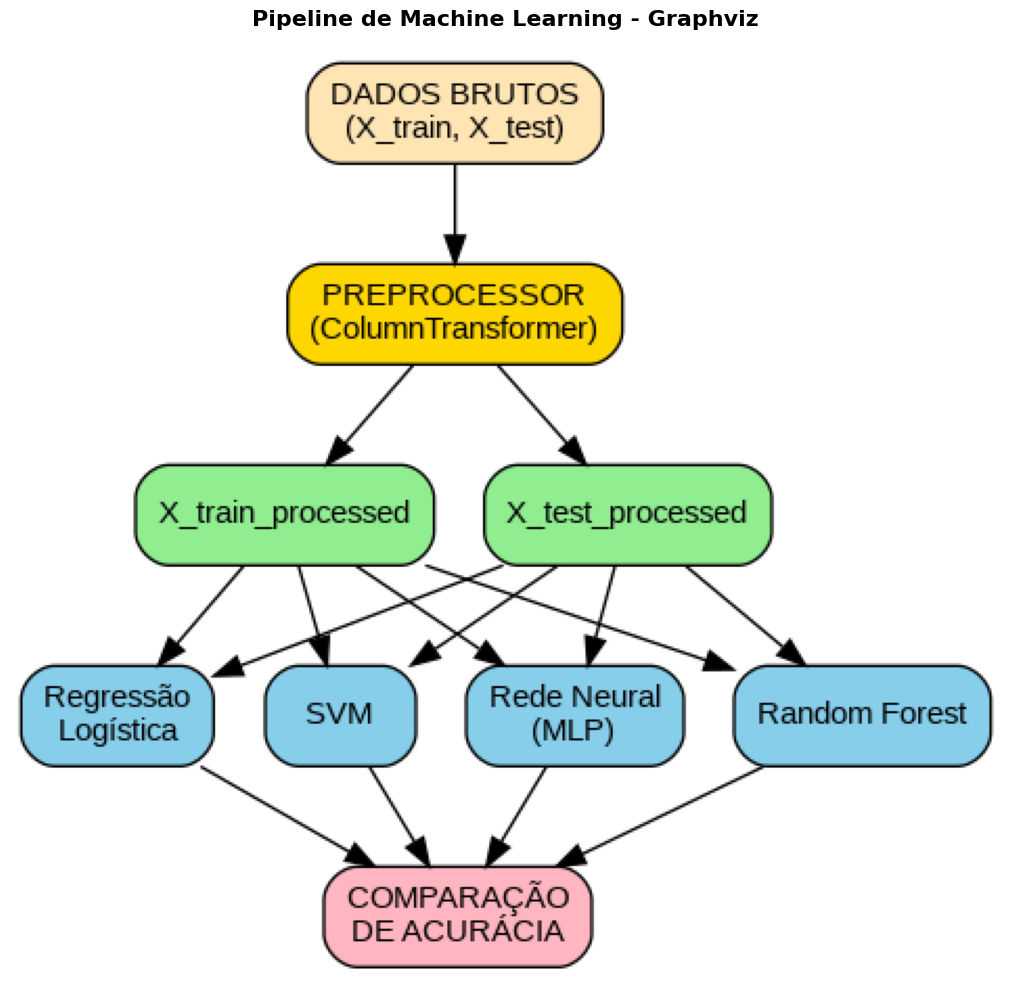

✅ Diagrama exibido na tela!


In [6]:
from graphviz import Digraph
import matplotlib.pyplot as plt
from PIL import Image
import os

# Criar o diagrama com Graphviz
fluxo = Digraph('Pipeline ML', format='png')
fluxo.attr(rankdir='TB')
fluxo.attr('node', shape='box', style='rounded,filled', fontname='Arial', fontsize='11')
fluxo.attr('graph', bgcolor='white')

# Nós
fluxo.node('dados', 'DADOS BRUTOS\n(X_train, X_test)', fillcolor='#FFE5B4', fontweight='bold')
fluxo.node('preprocessor', 'PREPROCESSOR\n(ColumnTransformer)', fillcolor='#FFD700', fontweight='bold')
fluxo.node('train_proc', 'X_train_processed', fillcolor='#90EE90', fontweight='bold')
fluxo.node('test_proc', 'X_test_processed', fillcolor='#90EE90', fontweight='bold')

# Modelos
fluxo.node('mlp', 'Rede Neural\n(MLP)', fillcolor='#87CEEB', fontweight='bold')
fluxo.node('rf', 'Random Forest', fillcolor='#87CEEB', fontweight='bold')
fluxo.node('lr', 'Regressão\nLogística', fillcolor='#87CEEB', fontweight='bold')
fluxo.node('svm', 'SVM', fillcolor='#87CEEB', fontweight='bold')

# Resultados
fluxo.node('comp', 'COMPARAÇÃO\nDE ACURÁCIA', fillcolor='#FFB6C1', fontweight='bold')

# Arestas
fluxo.edge('dados', 'preprocessor')
fluxo.edge('preprocessor', 'train_proc')
fluxo.edge('preprocessor', 'test_proc')

fluxo.edge('train_proc', 'mlp')
fluxo.edge('train_proc', 'rf')
fluxo.edge('train_proc', 'lr')
fluxo.edge('train_proc', 'svm')

fluxo.edge('test_proc', 'mlp')
fluxo.edge('test_proc', 'rf')
fluxo.edge('test_proc', 'lr')
fluxo.edge('test_proc', 'svm')

fluxo.edge('mlp', 'comp')
fluxo.edge('rf', 'comp')
fluxo.edge('lr', 'comp')
fluxo.edge('svm', 'comp')

# Salvar em PNG
print("⏳ Gerando diagrama Graphviz...")
fluxo.render('pipeline_ml_graphviz', view=False, cleanup=True)
print("✅ Diagrama salvo como 'pipeline_ml_graphviz.png'")

# Mostrar na tela usando Matplotlib
print("\n📺 Exibindo diagrama na tela...\n")
img = Image.open('pipeline_ml_graphviz.png')

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(img)
ax.axis('off')
plt.title('Pipeline de Machine Learning - Graphviz', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✅ Diagrama exibido na tela!")

### Diagrama do Processo - Matplotlib Puro (Sem Dependências Extras)

⏳ Gerando diagrama Matplotlib...
✅ Diagrama salvo como 'pipeline_ml_matplotlib.png'

📺 Exibindo diagrama na tela...



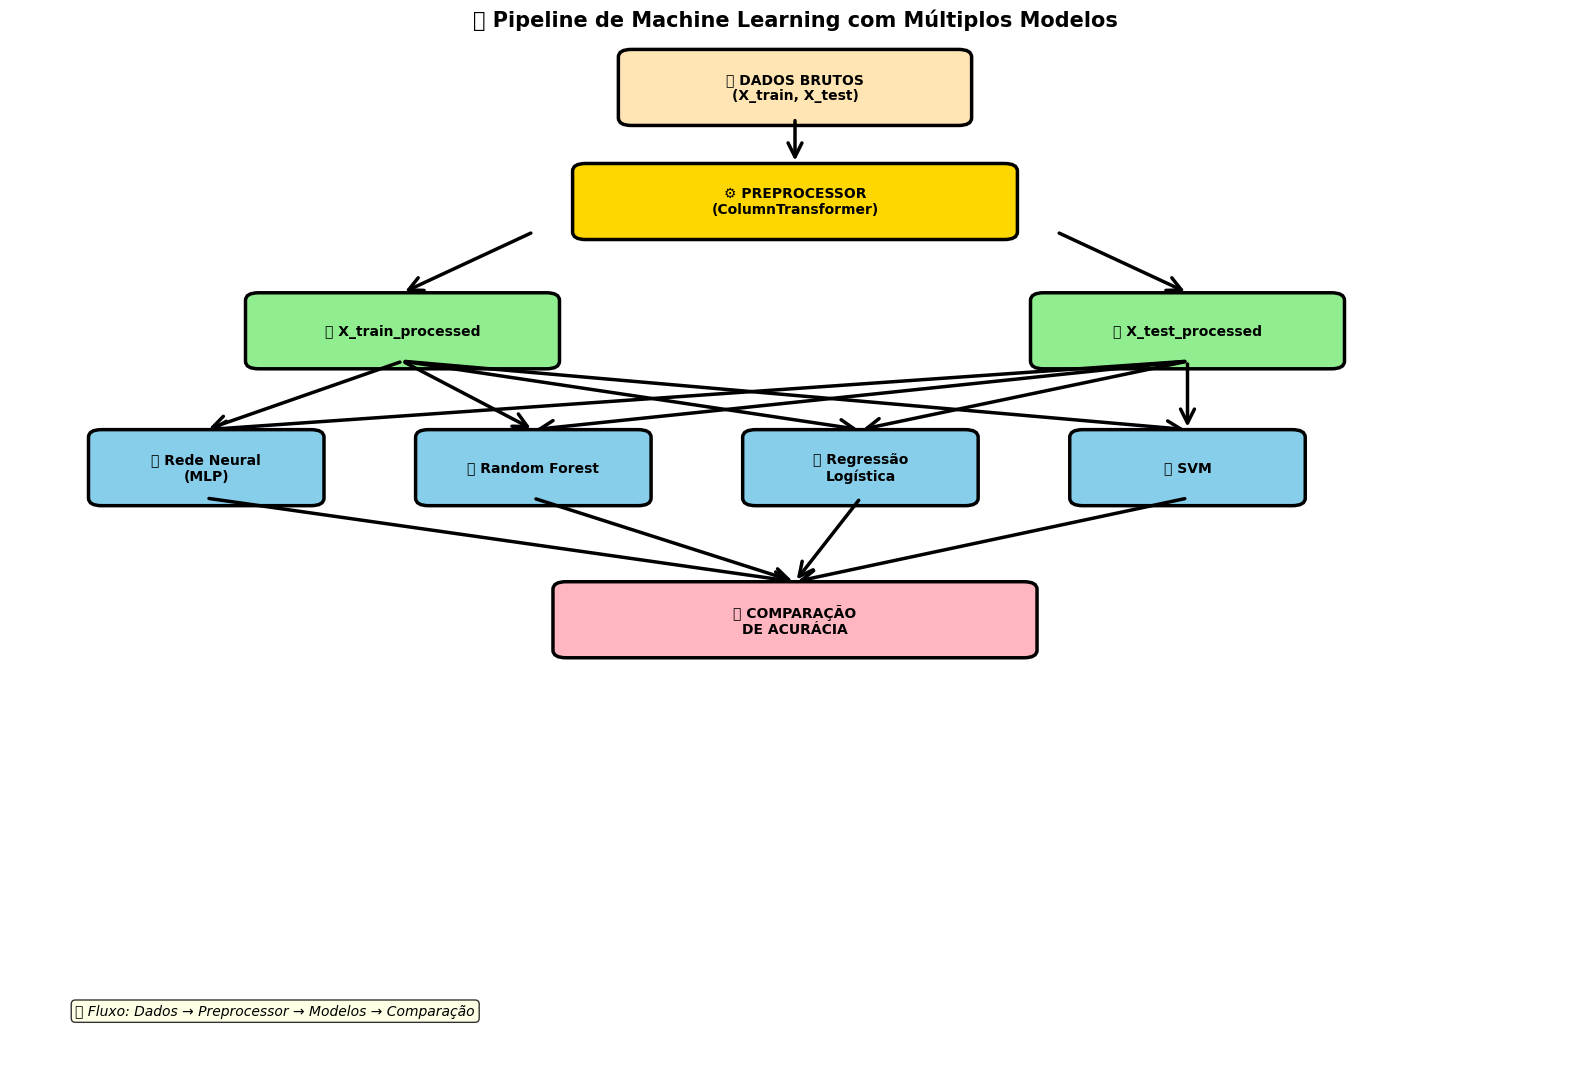

✅ Diagrama exibido na tela!


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

print("⏳ Gerando diagrama Matplotlib...")

fig, ax = plt.subplots(figsize=(16, 11))
ax.set_xlim(0, 12)
ax.set_ylim(0, 14)
ax.axis('off')

def caixa(x, y, w, h, texto, cor):
    """Desenha uma caixa arredondada"""
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                        boxstyle="round,pad=0.1",
                        edgecolor='black', facecolor=cor, linewidth=2.5)
    ax.add_patch(box)
    ax.text(x, y, texto, ha='center', va='center',
           fontsize=10, fontweight='bold')

def seta(x1, y1, x2, y2, cor='black'):
    """Desenha uma seta"""
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                           arrowstyle='->', mutation_scale=25,
                           linewidth=2.5, color=cor)
    ax.add_patch(arrow)

# Título
ax.text(6, 13.8, '🔄 Pipeline de Machine Learning com Múltiplos Modelos',
       ha='center', fontsize=15, fontweight='bold')

# Dados brutos
caixa(6, 13, 2.5, 0.8, '📊 DADOS BRUTOS\n(X_train, X_test)', '#FFE5B4')
seta(6, 12.6, 6, 12)

# Preprocessor
caixa(6, 11.5, 3.2, 0.8, '⚙️ PREPROCESSOR\n(ColumnTransformer)', '#FFD700')
seta(4, 11.1, 3, 10.3)
seta(8, 11.1, 9, 10.3)

# Dados processados
caixa(3, 9.8, 2.2, 0.8, '✅ X_train_processed', '#90EE90')
caixa(9, 9.8, 2.2, 0.8, '✅ X_test_processed', '#90EE90')

# Modelos
modelos = [
    (1.5, '🧠 Rede Neural\n(MLP)'),
    (4, '🌲 Random Forest'),
    (6.5, '📈 Regressão\nLogística'),
    (9, '🎯 SVM'),
]

for x_pos, nome in modelos:
    seta(3, 9.4, x_pos, 8.5)
    seta(9, 9.4, x_pos, 8.5)
    caixa(x_pos, 8, 1.6, 0.8, nome, '#87CEEB')
    seta(x_pos, 7.6, 6, 6.5)

# Comparação final
caixa(6, 6, 3.5, 0.8, '🏆 COMPARAÇÃO\nDE ACURÁCIA', '#FFB6C1')

# Legenda
ax.text(0.5, 0.8, '📌 Fluxo: Dados → Preprocessor → Modelos → Comparação',
       fontsize=10, style='italic',
       bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()

# Salvar em PNG
print("✅ Diagrama salvo como 'pipeline_ml_matplotlib.png'")
plt.savefig('pipeline_ml_matplotlib.png', dpi=300, bbox_inches='tight', facecolor='white')

# Mostrar na tela
print("\n📺 Exibindo diagrama na tela...\n")
plt.show()

print("✅ Diagrama exibido na tela!")

### Exercícios Práticos

 #### Desafio 1: Crie um modelo SVM (Support Vector Machine) e adicione à comparação.



#### Desafio 2: Aumente o Random Forest para 500 árvores. Melhora?

#### Desafio 3: Testar com uma nova flor




#### Desafio 4: Mostrar a matriz de confusão de todos os modelos Gerados
